# Registry, quality gate, and promotion

This notebook creates an **isolated local MLflow demo**. It calls the existing training CLI only to obtain real runs; Gate and Registry decisions always come from `invoiceops.ml.gate` and `invoiceops.ml.registry`.

- A **Run** records one experiment execution; a **Model Version** is a registered artifact from an eligible run.
- A **Gate** evaluates metrics; **Promotion** is a separate, explicit human action.
- **Latest** is chronological, not automatically **Best**.
- `champion` is a movable alias, not a rewritten model version.
- The Registry controls aliases; the serving runtime loads an alias only at startup.

In [1]:
import json
import os
import subprocess
import sys
from pathlib import Path

import mlflow
from mlflow.tracking import MlflowClient

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'pyproject.toml').is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
DEMO_ROOT = PROJECT_ROOT / 'var' / 't23_5_demo'
DEMO_ROOT.mkdir(parents=True, exist_ok=True)
STATE_PATH = DEMO_ROOT / 'state.json'
TRACKING_URI = f"sqlite:///{DEMO_ROOT / 'mlflow.db'}"
state = json.loads(STATE_PATH.read_text()) if STATE_PATH.exists() else {}
state.setdefault('candidates', {})
state.setdefault('registered_versions', {})
state.setdefault('completed_actions', {})
state.setdefault('promotion_history', [])
mlflow.set_tracking_uri(TRACKING_URI)
print(f'Isolated tracking URI: {TRACKING_URI}')

Isolated tracking URI: sqlite:////Users/admin/Desktop/elements/usach/diplomado/invoice_ops/invoice-ai/var/t23_5_demo/mlflow.db


## Real candidates

The setup invokes existing product training unchanged: two independently recorded `random_forest` runs (A/B) and a `dummy` run (C). The run IDs and metrics are read back from MLflow; nothing is fabricated. This batch does not require artificial algorithm diversity.

In [2]:
def save_state():
    STATE_PATH.write_text(json.dumps(state, indent=2, sort_keys=True) + '\n')

def run_training(model_type):
    environment = os.environ | {
        'MLFLOW_TRACKING_URI': TRACKING_URI,
        'PYTHONPATH': str(PROJECT_ROOT / 'src'),
    }
    result = subprocess.run(
        [sys.executable, '-m', 'invoiceops.ml.train', '--model', model_type],
        cwd=DEMO_ROOT, env=environment, check=True, text=True, capture_output=True,
    )
    print(result.stdout, end='')
    experiment = mlflow.get_experiment_by_name('invoice-risk')
    runs = mlflow.search_runs([experiment.experiment_id], order_by=['attributes.start_time DESC'])
    return str(runs.iloc[0]['run_id'])

for candidate, model_type in {'A': 'random_forest', 'B': 'random_forest', 'C': 'dummy'}.items():
    run_id = state['candidates'].get(candidate)
    if run_id is None:
        state['candidates'][candidate] = run_training(model_type)
save_state()
state['candidates']

model: random_forest
accuracy: 0.7883333333333333
precision: 0.4861111111111111
recall: 0.1856763925729443
f1: 0.2687140115163148
roc_auc: 0.6435026310835069


model: random_forest
accuracy: 0.7883333333333333
precision: 0.4861111111111111
recall: 0.1856763925729443
f1: 0.2687140115163148
roc_auc: 0.6435026310835069


model: dummy
accuracy: 0.7905555555555556
precision: 0.0
recall: 0.0
f1: 0.0
roc_auc: 0.5


{'A': 'e2b7cfd8abbb4631afc7f34aebac39b7',
 'B': 'dddca7b27b374e7fa3a30d695ee7228d',
 'C': '26504e3eafda4a9aa655b95af18e7528'}

,candidate,run_id,model_type,accuracy,precision,recall,f1,roc_auc,dataset_version,git_commit
0,A,e2b7cfd8abbb4631afc7f34aebac39b7,random_forest,0.788333,0.486111,0.185676,0.268714,0.643503,invoice-risk-v1,e4618dae304c2c061380b47dec676c02a10865d3
1,B,dddca7b27b374e7fa3a30d695ee7228d,random_forest,0.788333,0.486111,0.185676,0.268714,0.643503,invoice-risk-v1,e4618dae304c2c061380b47dec676c02a10865d3
2,C,26504e3eafda4a9aa655b95af18e7528,dummy,0.790556,0.000000,0.000000,0.000000,0.500000,invoice-risk-v1,e4618dae304c2c061380b47dec676c02a10865d3


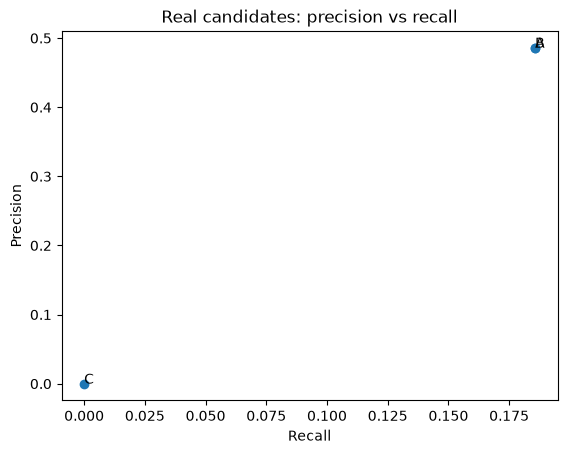

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

client = MlflowClient()
rows = []
for candidate, run_id in state['candidates'].items():
    run = client.get_run(run_id)
    rows.append({'candidate': candidate, 'run_id': run_id, **run.data.params, **run.data.metrics, **run.data.tags})
comparison = pd.DataFrame(rows)[[
    'candidate', 'run_id', 'model_type', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc',
    'dataset_version', 'git_commit',
]] .sort_values('candidate').reset_index(drop=True)
display(comparison)
plt.scatter(comparison['recall'], comparison['precision'])
for row in comparison.itertuples():
    plt.annotate(row.candidate, (row.recall, row.precision))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Real candidates: precision vs recall')
plt.show()

Which candidate has higher recall? Which has higher precision? Is there a universal winner? Which error costs the business more? The table is evidence for a human decision, not automatic selection.

In [4]:
from invoiceops.ml.gate import PRECISION_THRESHOLD, RECALL_THRESHOLD, evaluate_run

gate_rows = []
for candidate, run_id in state['candidates'].items():
    recall, precision = evaluate_run(run_id)
    recall_pass = recall >= RECALL_THRESHOLD
    precision_pass = precision >= PRECISION_THRESHOLD
    gate_rows.append({
        'candidate': candidate, 'run_id': run_id, 'model_type': comparison.set_index('candidate').at[candidate, 'model_type'],
        'recall': recall, 'precision': precision, 'recall_pass': recall_pass,
        'precision_pass': precision_pass, 'gate_status': 'PASS' if recall_pass and precision_pass else 'FAIL',
    })
gates = pd.DataFrame(gate_rows).sort_values('candidate').reset_index(drop=True)
display(gates)
assert (gates['gate_status'] == 'PASS').sum() == 2
assert (gates['gate_status'] == 'FAIL').sum() == 1
print('MODEL GATE results use invoiceops.ml.gate.evaluate_run.')

,candidate,run_id,model_type,recall,precision,recall_pass,precision_pass,gate_status
0,A,e2b7cfd8abbb4631afc7f34aebac39b7,random_forest,0.185676,0.486111,True,True,PASS
1,B,dddca7b27b374e7fa3a30d695ee7228d,random_forest,0.185676,0.486111,True,True,PASS
2,C,26504e3eafda4a9aa655b95af18e7528,dummy,0.000000,0.000000,False,False,FAIL


MODEL GATE results use invoiceops.ml.gate.evaluate_run.


## Registry state and guarded mutations

All cells below are marked **WARNING: MODIFIES STATE**. They reuse recorded versions/actions and query aliases before changing state. Versions are resolved dynamically; no `v1`/`v2` assumption is made.

In [5]:
# WARNING: MODIFIES STATE - register only Gate PASS candidates, once per isolated demo.
from notebooks._demo_helpers import run_mutable_action_once
from invoiceops.ml.registry import MODEL_NAME, promote_model, register_model

for candidate in ('A', 'B'):
    if gates.set_index('candidate').at[candidate, 'gate_status'] != 'PASS':
        raise RuntimeError(f'Candidate {candidate} did not pass the Quality Gate.')
    action = f'register-{candidate}'
    version = str(run_mutable_action_once(
        action, state['completed_actions'], lambda candidate=candidate: register_model(state['candidates'][candidate])
    ))
    state['registered_versions'][candidate] = version
save_state()
state['registered_versions']

Successfully registered model 'invoice-review'.
Created version '1' of model 'invoice-review'.
Registered model 'invoice-review' already exists. Creating a new version of this model...
Created version '2' of model 'invoice-review'.


{'A': '1', 'B': '2'}

In [6]:
# WARNING: MODIFIES STATE - explicit promotions A -> B -> A -> B, guarded per step.
def champion_version():
    try:
        return client.get_model_version_by_alias(MODEL_NAME, 'champion').version
    except Exception:
        return None

def promote_step(action, candidate):
    if gates.set_index('candidate').at[candidate, 'gate_status'] != 'PASS':
        raise RuntimeError('Promotion blocked: candidate did not pass Quality Gate.')
    target = str(state['registered_versions'][candidate])
    def promote_once():
        previous = champion_version()
        if previous != target:
            promote_model(target)
        state['promotion_history'].append({'step': len(state['promotion_history']) + 1, 'action': f'promote {candidate}', 'from': previous, 'to': target})
        return target
    return run_mutable_action_once(action, state['completed_actions'], promote_once)

for action, candidate in [('promote-A', 'A'), ('promote-B', 'B'), ('switch-to-A', 'A'), ('final-champion-B', 'B')]:
    promote_step(action, candidate)
save_state()
display(pd.DataFrame(state['promotion_history']))
print(f"Champion alias now resolves to version {champion_version()}")

,step,action,from,to
0,1,promote A,NaN,1
1,2,promote B,1.0,2
2,3,promote A,2.0,1
3,4,promote B,1.0,2


Champion alias now resolves to version 2


In [7]:
# WARNING: MODIFIES STATE - this guard intentionally blocks Candidate C before Registry promotion.
try:
    promote_step('promote-C', 'C')
except RuntimeError as error:
    print(error)
assert 'C' not in state['registered_versions']
print('Candidate C remains a valid run but is ineligible for promotion.')

Promotion blocked: candidate did not pass Quality Gate.
Candidate C remains a valid run but is ineligible for promotion.


In [8]:
versions = client.search_model_versions(f"name='{MODEL_NAME}'")
registry_rows = []
for version in versions:
    aliases = []
    for alias in ('challenger', 'champion'):
        try:
            if client.get_model_version_by_alias(MODEL_NAME, alias).version == version.version:
                aliases.append(alias)
        except Exception:
            pass
    run = client.get_run(version.run_id)
    registry_rows.append({'version': version.version, 'run_id': version.run_id, 'model_type': run.data.params.get('model_type'), 'aliases': ', '.join(aliases), 'created_at': version.creation_timestamp})
display(pd.DataFrame(registry_rows).sort_values('version'))
print('Changing an alias never rewrites or deletes a Model Version.')

,version,run_id,model_type,aliases,created_at
1,1,e2b7cfd8abbb4631afc7f34aebac39b7,random_forest,,1787731911763
0,2,dddca7b27b374e7fa3a30d695ee7228d,random_forest,"challenger, champion",1787731911871


Changing an alias never rewrites or deletes a Model Version.
